In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [2]:
n=500
m=500
G = nx.gnm_random_graph(n, m)
edges = list(G.edges())
t = sum(nx.triangles(G).values()) // 3
its = 500000
burn_in = 50000
up_tris = []
down_tris = []
up_vars = []
down_vars = []
deg_sq_sum = sum(d**2 for _, d in G.degree())

b_vals = np.linspace(0, 10, 35)
import time
for b in b_vals:
    total_edges = 0
    total_tris = 0
    total_var = 0
    start_time = time.time()
    for _ in range(its):
        current_edge = edges[np.random.randint(len(edges))]
        new_edge = (np.random.randint(0, n), np.random.randint(0, n))
        while new_edge[0] == new_edge[1] or G.has_edge(new_edge[0], new_edge[1]):
            new_edge = (np.random.randint(0, n), np.random.randint(0, n))
        
        deg_c0 = len(G[current_edge[0]])
        deg_c1 = len(G[current_edge[1]])
        deg_n0 = len(G[new_edge[0]])
        deg_n1 = len(G[new_edge[1]])

        delta_deg_sq = 2*(deg_n0 + deg_n1 - deg_c0 - deg_c1)+4
        delta_t = len(list(nx.common_neighbors(G, new_edge[0], new_edge[1]))) - len(list(nx.common_neighbors(G, current_edge[0], current_edge[1])))
        G.remove_edge(*current_edge)
        G.add_edge(*new_edge)
        
        dH = b * delta_t
        if np.log(np.random.uniform()) <= dH:
            t += delta_t
            deg_sq_sum += delta_deg_sq
            edges.remove(current_edge)
            edges.append(new_edge)
        else:
            # revert
            G.remove_edge(*new_edge)
            G.add_edge(*current_edge)
        
        if _ >= burn_in:
            total_edges += m
            total_tris += t
            total_var += deg_sq_sum/n - (2*m/n)**2
    print(b, time.time() - start_time)
    up_tris.append(total_tris / (its-burn_in))
    up_vars.append(total_var / (its-burn_in))

for b in reversed(b_vals):
    total_edges = 0
    total_tris = 0
    total_var = 0
    start_time = time.time()
    for _ in range(its):
        current_edge = edges[np.random.randint(len(edges))]
        new_edge = (np.random.randint(0, n), np.random.randint(0, n))
        while new_edge[0] == new_edge[1] or G.has_edge(new_edge[0], new_edge[1]):
            new_edge = (np.random.randint(0, n), np.random.randint(0, n))
        
        deg_c0 = len(G[current_edge[0]])
        deg_c1 = len(G[current_edge[1]])
        deg_n0 = len(G[new_edge[0]])
        deg_n1 = len(G[new_edge[1]])

        delta_deg_sq = 2*(deg_n0 + deg_n1 - deg_c0 - deg_c1)+4
        delta_t = len(list(nx.common_neighbors(G, new_edge[0], new_edge[1]))) - len(list(nx.common_neighbors(G, current_edge[0], current_edge[1])))
        G.remove_edge(*current_edge)
        G.add_edge(*new_edge)
        
        dH = b * delta_t
        if np.log(np.random.uniform()) <= dH:
            t += delta_t
            deg_sq_sum += delta_deg_sq
            edges.remove(current_edge)
            edges.append(new_edge)
        else:
            # revert
            G.remove_edge(*new_edge)
            G.add_edge(*current_edge)
        
        if _ >= burn_in:
            total_edges += m
            total_tris += t
            total_var += deg_sq_sum/n - (2*m/n)**2
    print(b, time.time() - start_time)
    down_tris.append(total_tris / (its-burn_in))
    down_vars.append(total_var / (its-burn_in))


plt.figure()
plt.scatter(b_vals, up_tris, label='upsweep', marker = 'o')
plt.scatter(b_vals[::-1], down_tris, label = 'downsweep', marker = '^')

plt.figure()
plt.scatter(b_vals, up_vars, label='upsweep', marker = 'o') 
plt.scatter(b_vals[::-1], down_vars, label = 'downsweep', marker = '^')
plt.show()


0.0 5.810977935791016
0.29411764705882354 5.774487018585205
0.5882352941176471 5.757853984832764
0.8823529411764706 5.68443489074707
1.1764705882352942 5.796443939208984
1.4705882352941178 5.808876276016235
1.7647058823529411 5.84536075592041
2.058823529411765 5.758244037628174
2.3529411764705883 5.852381229400635
2.6470588235294117 5.864639520645142
2.9411764705882355 5.992486476898193
3.235294117647059 5.94687032699585


KeyboardInterrupt: 

Starting Upsweep...
b=0.00 | Converged in 1000000 steps | Time: 9.78s
b=0.29 | Converged in 1000000 steps | Time: 9.74s
b=0.59 | Converged in 1000000 steps | Time: 9.78s
b=0.88 | Converged in 1000000 steps | Time: 9.76s
b=1.18 | Converged in 1000000 steps | Time: 9.69s
b=1.47 | Converged in 1000000 steps | Time: 9.77s
b=1.76 | Converged in 1000000 steps | Time: 9.73s
b=2.06 | Converged in 1000000 steps | Time: 9.77s
b=2.35 | Converged in 1000000 steps | Time: 9.78s
b=2.65 | Converged in 1000000 steps | Time: 9.88s
b=2.94 | Converged in 1000000 steps | Time: 10.56s
b=3.24 | Converged in 1000000 steps | Time: 12.41s
b=3.53 | Converged in 1000000 steps | Time: 12.43s
b=3.82 | Converged in 900000 steps | Time: 11.28s
b=4.12 | Converged in 800000 steps | Time: 10.16s
b=4.41 | Converged in 200000 steps | Time: 3.46s
b=4.71 | Converged in 200000 steps | Time: 3.37s
b=5.00 | Converged in 300000 steps | Time: 4.51s
b=5.29 | Converged in 200000 steps | Time: 3.38s
b=5.59 | Converged in 200000 st

RuntimeError: matplotlib does not support generators as input

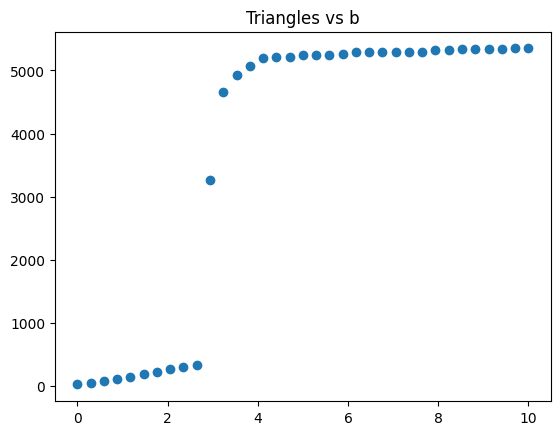

In [7]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import time

def mcmc_step(G, edges, t, deg_sq_sum, b, n):
    """Performs a single Metropolis-Hastings edge-swap step."""
    current_idx = np.random.randint(len(edges))
    current_edge = edges[current_idx]
    
    new_edge = (np.random.randint(0, n), np.random.randint(0, n))
    while new_edge[0] == new_edge[1] or G.has_edge(new_edge[0], new_edge[1]):
        new_edge = (np.random.randint(0, n), np.random.randint(0, n))
    
    deg_c0 = len(G[current_edge[0]])
    deg_c1 = len(G[current_edge[1]])
    deg_n0 = len(G[new_edge[0]])
    deg_n1 = len(G[new_edge[1]])

    delta_deg_sq = 2 * (deg_n0 + deg_n1 - deg_c0 - deg_c1) + 4
    
    cn_new = sum(1 for _ in nx.common_neighbors(G, new_edge[0], new_edge[1]))
    cn_curr = sum(1 for _ in nx.common_neighbors(G, current_edge[0], current_edge[1]))
    delta_t = cn_new - cn_curr
    
    G.remove_edge(*current_edge)
    G.add_edge(*new_edge)
    
    dH = b * delta_t
    if np.log(np.random.uniform()) <= dH:
        t += delta_t
        deg_sq_sum += delta_deg_sq
        edges[current_idx] = new_edge 
    else:
        G.remove_edge(*new_edge)
        G.add_edge(*current_edge)
        
    return t, deg_sq_sum

def run_sweep(b_vals, G, edges, t, deg_sq_sum, n, m, max_burn_in=1000000, window_size=100000, tol=1e-3, sample_its=100000):
    """
    Runs the MCMC sweep and returns the updated metrics alongside the results.
    """
    tris_results = []
    vars_results = []
    
    for b in b_vals:
        start_time = time.time()
        
        # 1. Dynamic Burn-in Phase
        prev_mean_t = -1
        current_t_sum = 0
        step = 0
        converged = False
        
        while step < max_burn_in and not converged:
            for _ in range(window_size):
                t, deg_sq_sum = mcmc_step(G, edges, t, deg_sq_sum, b, n)
                current_t_sum += t
                step += 1
            
            current_mean_t = current_t_sum / window_size
            if prev_mean_t != -1:
                diff = abs(current_mean_t - prev_mean_t)
                rel_diff = diff / current_mean_t if current_mean_t > 0 else diff
                if rel_diff < tol:
                    converged = True
                    
            prev_mean_t = current_mean_t
            current_t_sum = 0
            
        # 2. Sampling Phase (post-convergence)
        total_tris = 0
        total_var = 0
        for _ in range(sample_its):
            t, deg_sq_sum = mcmc_step(G, edges, t, deg_sq_sum, b, n)
            total_tris += t
            total_var += (deg_sq_sum / n) - (2 * m / n)**2
            
        avg_tris = total_tris / sample_its
        avg_var = total_var / sample_its
        
        tris_results.append(avg_tris)
        vars_results.append(avg_var)
        
        print(f"b={b:.2f} | Converged in {step} steps | Time: {time.time() - start_time:.2f}s")
        
    return tris_results, vars_results, t, deg_sq_sum

# Initialization
n = 500
m = 500
G = nx.gnm_random_graph(n, m)
edges = list(G.edges())
t = sum(nx.triangles(G).values()) // 3
deg_sq_sum = sum(d**2 for _, d in G.degree())

b_vals = np.linspace(0, 10, 35)

# Upsweep
print("Starting Upsweep...")
up_tris, up_vars, t, deg_sq_sum = run_sweep(b_vals, G, edges, t, deg_sq_sum, n, m)

# Downsweep
print("\nStarting Downsweep...")
down_b_vals = reversed(b_vals)
down_tris, down_vars, t, deg_sq_sum = run_sweep(down_b_vals, G, edges, t, deg_sq_sum, n, m)

# Plotting
plt.figure()
plt.title('Triangles vs b')
plt.scatter(b_vals, up_tris, label='upsweep', marker='o')
plt.scatter(down_b_vals, down_tris, label='downsweep', marker='^')
plt.xlabel('b')
plt.ylabel('Average Triangles')
plt.legend()

plt.figure()
plt.title('Variance vs b')
plt.scatter(b_vals, up_vars, label='upsweep', marker='o') 
plt.scatter(down_b_vals, down_vars, label='downsweep', marker='^')
plt.xlabel('b')
plt.ylabel('Average Variance')
plt.legend()

plt.show()

In [15]:
import matplotlib.pyplot as plt
up_tris = np.array(up_tris)
up_tris = up_tris * (n*(n-1)*(n-2)/6)
down_tris = np.array(down_tris)
down_tris = down_tris * (n*(n-1)*(n-2)/6)

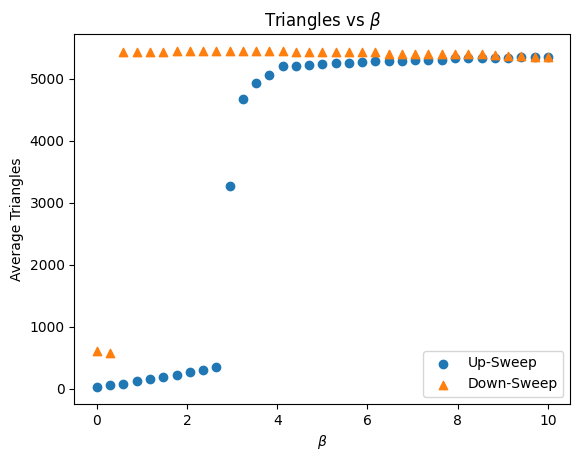

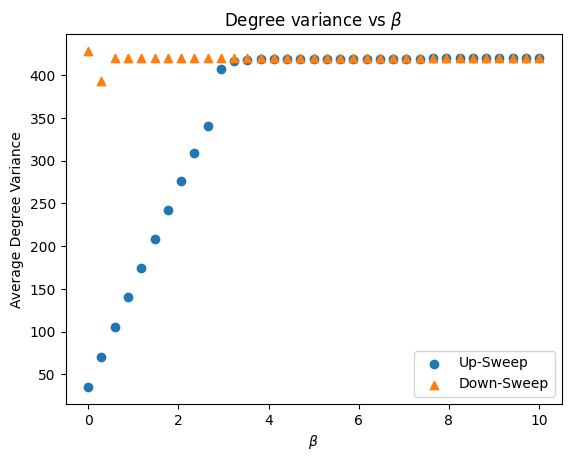

In [17]:
plt.figure()
plt.title(r'Triangles vs $\beta$')
plt.scatter(b_vals, up_tris, label='Up-Sweep', marker='o')
plt.scatter(b_vals[::-1], down_tris, label='Down-Sweep', marker='^')
plt.xlabel(r'$\beta$')
plt.ylabel('Average Triangles')
plt.legend()

plt.figure()
plt.title(r'Degree variance vs $\beta$')
plt.scatter(b_vals, up_vars, label='Up-Sweep', marker='o') 
plt.scatter(b_vals[::-1], down_vars, label='Down-Sweep', marker='^')
plt.xlabel(r'$\beta$')
plt.ylabel('Average Degree Variance')
plt.legend()

plt.show()